# Phase 1.5 — 변동성 LSTM 본 실험 (`02_volatility_lstm.ipynb`)

> **목적**: Log-RV 타깃에 대해 LSTM 학습·평가 (Walk-Forward 90 fold × SPY/QQQ).
>
> **Phase 1 과의 차이점**:
> - 타깃: 누적 수익률 → **Log Realized Volatility**
> - 입력: log_ret → **log_ret²** (instantaneous variance proxy)
> - 손실: Huber → **MSE**
> - Walk-Forward: IS 231/embargo 21 → **IS 504/embargo 63** (정밀도 우선, EDA §5-확장 결과 반영)
> - fold 수: 105 → **90**
> - 평가지표: hit_rate/r2_oos → **rmse / qlike / r2_train_mean / MZ / pred_std_ratio**

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 |
| §2 | 데이터 로드 + log_ret · log_ret² · target 생성 |
| §3 | 타깃 누수 검증 |
| §4 | SequenceDataset 점검 |
| §5 | Walk-Forward fold 생성 (90 fold) |
| §6 | LSTMRegressor smoke test |
| §7 | run_all_folds helper |
| §8 | **90 fold × 2 ticker 학습** (실행 시간 30~60분 CPU) |
| §9 | 평가 + 진단 6종 (§9.A~F) |
| §10 | metrics.json 저장 + 결론 |

## 사용자 체크포인트
- §3 누수 검증 PASS
- §6 모델 smoke test 정상
- §8 학습 첫 fold loss curve 정상
- §10 종합 메트릭 보고 → §03 베이스라인 비교 진행 승인


## §1. 환경 부트스트랩

`scripts/setup.py` 의 `bootstrap()` 한 줄로 환경 일괄 설정 (Phase 1 동일 패턴).


In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()
print(f"BASE_DIR     = {BASE_DIR}")
print(f"RAW_DATA_DIR = {RAW_DATA_DIR}")
print(f"RESULTS_DIR  = {RESULTS_DIR}")


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
BASE_DIR     = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
RAW_DATA_DIR = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data
RESULTS_DIR  = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results


## §2. 데이터 로드 + log_ret · log_ret² · target 생성

- **데이터**: Phase 1 raw_data 사본 (SPY/QQQ.csv) 재사용 (재다운로드 X)
- **분석 기간**: 2016-01-01 ~ 2025-12-31 (10년, 2,514 영업일)
- **입력 시계열**: `log_ret²` (instantaneous variance proxy, 단일 채널)
- **타깃 시계열**: `build_daily_target_logrv_21d(adj_close)` 결과


In [2]:
import pandas as pd
import numpy as np
from scripts.targets_volatility import build_daily_target_logrv_21d

ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21          # forward window
SEQ_LEN = 63          # PLAN 확정값 — Phase 1 3차 Run 과 동일 (정밀도 우선 시에도 유지)

def load_ticker(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df

raw_dict = {'SPY': load_ticker('SPY'), 'QQQ': load_ticker('QQQ')}

# 분석 기간 절단 + 타깃 생성
analysis_dict = {}
for tk, raw in raw_dict.items():
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    df['log_ret_sq'] = df['log_ret'] ** 2          # 입력 시계열 (variance proxy)
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    analysis_dict[tk] = df
    n = len(df)
    n_valid_target = int(df['target_logrv'].notna().sum())
    print(f'{tk}: n={n}, 유효 타깃={n_valid_target} (마지막 {WINDOW}행 NaN)')


SPY: n=2514, 유효 타깃=2493 (마지막 21행 NaN)
QQQ: n=2514, 유효 타깃=2493 (마지막 21행 NaN)


## §3. 타깃 누수 검증 (PLAN §9 — 변동성 특수 함정 5종)

`verify_no_leakage_logrv` 로 SPY/QQQ 모두 검증. assert + 5행 육안 표.


In [3]:
from scripts.targets_volatility import verify_no_leakage_logrv

for tk in ('SPY', 'QQQ'):
    print('=' * 70)
    print(f'{tk} Log-RV 누수 검증')
    print('=' * 70)
    df = analysis_dict[tk]
    verify_no_leakage_logrv(
        df['Adj Close'], df['target_logrv'],
        n_checks=3, window=WINDOW, seed=42, ddof=1,
    )
    print()


SPY Log-RV 누수 검증
=== Log-RV 누수 검증 1 — Assert 단위 테스트 ===
  [PASS] 2016-11-17  target=-5.337418  직접계산=-5.337418  Δ=1.78e-15
  [PASS] 2022-06-27  target=-4.369255  직접계산=-4.369255  Δ=8.88e-16
  [PASS] 2023-08-31  target=-4.999196  직접계산=-4.999196  Δ=6.22e-15

=== Log-RV 누수 검증 2 — 육안 확인 표 (첫 5개 유효 행) ===
            날짜     log_ret      target        직접계산    일치
  ------------------------------------------------------
    2016-01-04         NaN   -4.220238   -4.220238     O
    2016-01-05    0.001690   -4.220351   -4.220351     O
    2016-01-06   -0.012694   -4.200395   -4.200395     O
    2016-01-07   -0.024284   -4.241430   -4.241430     O
    2016-01-08   -0.011037   -4.251140   -4.251140     O

[OK] Log-RV 누수 검증 완료 — 모든 체크포인트 PASS

QQQ Log-RV 누수 검증
=== Log-RV 누수 검증 1 — Assert 단위 테스트 ===
  [PASS] 2016-11-17  target=-4.900030  직접계산=-4.900030  Δ=8.88e-16
  [PASS] 2022-06-27  target=-4.006628  직접계산=-4.006628  Δ=8.88e-16
  [PASS] 2023-08-31  target=-4.705041  직접계산=-4.705041  Δ=7.99e-15

=== Log

## §4. SequenceDataset 점검

`scripts/dataset.py` 의 `build_fold_datasets` 가 정상 작동하는지 fold 0 하나로 smoke 점검.

- `series`: log_ret² 시계열 (.values, NaN 채우기 후)
- `target_series`: target_logrv 시계열 (.values)
- 누수 방지: scaler 는 train 만 fit


In [4]:
from scripts.dataset import build_fold_datasets, walk_forward_folds

# 유효 타깃 수 산출 (NaN 제외) — Phase 1 의 fold 105 NaN 혼입 버그 회피
N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in ('SPY', 'QQQ'))
print(f'유효 타깃 수 (min over SPY/QQQ): {N_VALID}')

# series, target 준비 (NaN 위치 처리: log_ret 첫 행 NaN → 0 채움, target NaN 은 fold 슬라이싱으로 자동 회피)
series_dict = {}
target_dict = {}
for tk in ('SPY', 'QQQ'):
    df = analysis_dict[tk]
    series_dict[tk] = df['log_ret_sq'].fillna(0.0).values     # log_ret 첫 행 NaN → 0
    target_dict[tk] = df['target_logrv'].values                # NaN 마지막 21행 (fold 가 회피)

# Smoke: fold 0 으로 dataset 생성 시도
sample_folds = walk_forward_folds(
    n=N_VALID, is_len=504, purge=21, emb=63, oos_len=21, step=21,
)
print(f'생성된 fold 수: {len(sample_folds)}')
print(f'첫 fold: train_idx={sample_folds[0][0][:3]}...{sample_folds[0][0][-3:]}, '
      f'test_idx={sample_folds[0][1][:3]}...{sample_folds[0][1][-3:]}')

train_ds_smoke, test_ds_smoke, scaler_smoke = build_fold_datasets(
    series=series_dict['SPY'],
    train_idx=sample_folds[0][0],
    test_idx=sample_folds[0][1],
    seq_len=SEQ_LEN,
    target_series=target_dict['SPY'],
)
print(f'Smoke (SPY fold 0): train X.shape={train_ds_smoke.X.shape}, y.shape={train_ds_smoke.y.shape}')
print(f'                    test  X.shape={test_ds_smoke.X.shape},  y.shape={test_ds_smoke.y.shape}')
print(f'                    scaler.mean_={scaler_smoke.mean_}, scaler.scale_={scaler_smoke.scale_}')


유효 타깃 수 (min over SPY/QQQ): 2493
생성된 fold 수: 90
첫 fold: train_idx=[0 1 2]...[501 502 503], test_idx=[588 589 590]...[606 607 608]
Smoke (SPY fold 0): train X.shape=torch.Size([441, 63, 1]), y.shape=torch.Size([441])
                    test  X.shape=torch.Size([21, 63, 1]),  y.shape=torch.Size([21])
                    scaler.mean_=[4.32624368e-05], scaler.scale_=[0.00010531]


## §5. Walk-Forward fold 생성 (90 fold)

PLAN §7-6 (정밀도 우선, 2026-04-26 갱신):
- IS=504 / Purge=21 / Embargo=63 / OOS=21 / Step=21 → **90 fold**
- 훈련 샘플 fold 당 441 (Phase 1 의 134 대비 3.3배)


In [5]:
IS_LEN = 504
PURGE = 21
EMBARGO = 63
OOS_LEN = 21
STEP = 21

folds_list = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO, oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds_list)
print(f'생성된 fold 수: {N_FOLDS} (예상 90)')
print(f'fold 당 훈련 샘플: IS({IS_LEN}) - seq_len({SEQ_LEN}) = {IS_LEN - SEQ_LEN}')
print(f'fold 당 OOS 샘플: {OOS_LEN}')
print(f'전체 OOS 샘플 수: {N_FOLDS * OOS_LEN}')


생성된 fold 수: 90 (예상 90)
fold 당 훈련 샘플: IS(504) - seq_len(63) = 441
fold 당 OOS 샘플: 21
전체 OOS 샘플 수: 1890


## §6. LSTMRegressor smoke test

Phase 1 동일 모델 구조 (capacity 비교 가능). input_size=1 (log_ret² 단일 채널).


In [6]:
import torch
from scripts.models import LSTMRegressor

HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.3
INPUT_SIZE = 1   # log_ret² 단일 채널 (1차 시도, HAR 다채널은 추후)

model_smoke = LSTMRegressor(
    input_size=INPUT_SIZE, hidden_size=HIDDEN,
    num_layers=NUM_LAYERS, dropout=DROPOUT, batch_first=True,
)
n_params = sum(p.numel() for p in model_smoke.parameters() if p.requires_grad)
print(f'LSTMRegressor: input_size={INPUT_SIZE}, hidden={HIDDEN}, num_layers={NUM_LAYERS}, dropout={DROPOUT}')
print(f'학습 가능 파라미터 수: {n_params:,} (Phase 1 3차 Run 과 동일 4,513 예상)')

# Smoke forward pass
xb_smoke = train_ds_smoke.X[:4]
yb_smoke_pred = model_smoke(xb_smoke)
print(f'Smoke forward: input shape={tuple(xb_smoke.shape)}, output shape={tuple(yb_smoke_pred.shape)}')


LSTMRegressor: input_size=1, hidden=32, num_layers=1, dropout=0.3
학습 가능 파라미터 수: 4,513 (Phase 1 3차 Run 과 동일 4,513 예상)
Smoke forward: input shape=(4, 63, 1), output shape=(4,)


## §7. run_all_folds helper — 단일 ticker 의 90 fold 학습·예측 수집

Phase 1 패턴 차용. 차이점:
- `loss_type='mse'` 명시 (Huber → MSE)
- input_size=1 (log_ret² 단일 채널)
- weight_decay=1e-3, max_epochs=30, early_stop_patience=5, lr_patience=3 (Phase 1 3차 Run 동일)

fold 모델 state_dict 는 디스크 저장 X (일회용 + 재현성은 seed=42 로 확보).


In [7]:
import time
from torch.utils.data import TensorDataset, DataLoader
from scripts.train import train_one_fold, get_device

# 학습 하이퍼파라미터 — 호출부와 §9 hyperparams dict 모두 이 변수 참조
MAX_EPOCHS   = 30
PATIENCE     = 5
LR_PATIENCE  = 3
LR           = 1e-3
WEIGHT_DECAY = 1e-3
LOSS_TYPE    = 'mse'      # Phase 1.5 변경 (Phase 1 'huber' 대비)
VAL_RATIO    = 0.2

def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=32):
    """IS 훈련을 시간순 80/20 으로 재분할 (val 은 뒤쪽 20% — 최신 구간)."""
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub   = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def run_all_folds(
    ticker: str, series: np.ndarray, target: np.ndarray, folds: list, seq_len: int,
    *,
    input_size: int = 1,
    hidden: int = HIDDEN, num_layers: int = NUM_LAYERS, dropout: float = DROPOUT,
    max_epochs: int = MAX_EPOCHS, patience: int = PATIENCE,
    lr: float = LR, weight_decay: float = WEIGHT_DECAY,
    lr_patience: int = LR_PATIENCE,
    loss_type: str = LOSS_TYPE,
    log_every: int = 15, device=None,
):
    """단일 ticker 의 90 fold 학습·예측 수집 (train/val/test 모두)."""
    device = get_device('auto') if device is None else torch.device(device)
    print(f'  [{ticker}] device: {device}, n_folds={len(folds)}')
    fold_out = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series=series, train_idx=tr_idx, test_idx=te_idx,
            seq_len=seq_len, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k, val_ratio=VAL_RATIO)
        model_k = LSTMRegressor(
            input_size=input_size, hidden_size=hidden, num_layers=num_layers,
            dropout=dropout, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=max_epochs, early_stop_patience=patience,
            lr=lr, weight_decay=weight_decay,
            lr_patience=lr_patience,
            loss_type=loss_type,
            device=device, verbose=False,
        )
        # best 로 train(IS 80%) / val(IS 20%) / test(OOS) 모두 예측
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred_oos = model_k(te_ds_k.X.to(device)).cpu().numpy()
            n_tr_used  = len(tr_loader.dataset)
            y_pred_train = model_k(tr_ds_k.X[:n_tr_used].to(device)).cpu().numpy()
            y_pred_val   = model_k(tr_ds_k.X[n_tr_used:].to(device)).cpu().numpy()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        fold_out.append({
            'fold': k,
            'train_idx_first': int(tr_idx[0]), 'train_idx_last': int(tr_idx[-1]),
            'test_idx_first': int(te_idx[0]),  'test_idx_last': int(te_idx[-1]),
            'y_true_test':  te_ds_k.y.numpy().astype(float).tolist(),
            'y_pred_test':  y_pred_oos.flatten().astype(float).tolist(),
            'y_true_train': tr_ds_k.y[:n_tr_used].numpy().astype(float).tolist(),
            'y_pred_train': y_pred_train.flatten().astype(float).tolist(),
            'y_true_val':   tr_ds_k.y[n_tr_used:].numpy().astype(float).tolist(),
            'y_pred_val':   y_pred_val.flatten().astype(float).tolist(),
            'best_epoch':   int(result['best_epoch']),
            'best_val_loss': float(result['best_val_loss']),
            'stopped_early': bool(result['stopped_early']),
            'history':      {k: [float(v) for v in vs] for k, vs in result['history'].items()},
        })
        if (k + 1) % log_every == 0 or k == len(folds) - 1:
            elapsed = time.time() - t_start
            avg = elapsed / (k + 1)
            eta = avg * (len(folds) - k - 1)
            print(f'    [{ticker}] fold {k+1}/{len(folds)} '
                  f'best_ep={result["best_epoch"]:>2}, val_loss={result["best_val_loss"]:.4f} '
                  f'| elapsed={elapsed/60:.1f}m, ETA={eta/60:.1f}m')
    return fold_out


## §8. SPY · QQQ 90 fold 학습 ⏳

⚠️ **실행 시간**: CPU 기준 약 30~60분 (Phase 1 105 fold 의 IS 504 확장 버전).

학습 과정 모니터링: 15 fold 마다 진행률·ETA 출력.


In [8]:
print('=' * 70)
print('SPY 학습 시작')
print('=' * 70)
spy_folds_out = run_all_folds(
    ticker='SPY',
    series=series_dict['SPY'], target=target_dict['SPY'],
    folds=folds_list, seq_len=SEQ_LEN,
)
print()
print('=' * 70)
print('QQQ 학습 시작')
print('=' * 70)
qqq_folds_out = run_all_folds(
    ticker='QQQ',
    series=series_dict['QQQ'], target=target_dict['QQQ'],
    folds=folds_list, seq_len=SEQ_LEN,
)
print()
print(f'학습 완료: SPY {len(spy_folds_out)} fold, QQQ {len(qqq_folds_out)} fold')


SPY 학습 시작
  [SPY] device: cpu, n_folds=90


    [SPY] fold 15/90 best_ep= 8, val_loss=0.2049 | elapsed=0.2m, ETA=0.8m


    [SPY] fold 30/90 best_ep= 6, val_loss=0.3042 | elapsed=0.3m, ETA=0.6m


    [SPY] fold 45/90 best_ep= 8, val_loss=0.2757 | elapsed=0.4m, ETA=0.4m


    [SPY] fold 60/90 best_ep= 6, val_loss=0.0393 | elapsed=0.6m, ETA=0.3m


...

    [QQQ] fold 30/90 best_ep= 6, val_loss=0.2877 | elapsed=0.3m, ETA=0.5m


    [QQQ] fold 45/90 best_ep= 8, val_loss=0.4119 | elapsed=0.4m, ETA=0.4m


    [QQQ] fold 60/90 best_ep= 8, val_loss=0.0281 | elapsed=0.5m, ETA=0.3m


    [QQQ] fold 75/90 best_ep= 9, val_loss=0.1332 | elapsed=0.6m, ETA=0.1m


    [QQQ] fold 90/90 best_ep= 7, val_loss=0.2960 | elapsed=0.8m, ETA=0.0m

학습 완료: SPY 90 fold, QQQ 90 fold


## §9. 평가 — 메트릭 산출 + Train-Mean baseline

### Phase 1.5 1차 메트릭 (PLAN §6 PASS 조건 평가용)
- **rmse on Log-RV** — 베이스라인 비교용
- **qlike** — Patton(2011) 비대칭 손실
- **r2_train_mean** — train 평균 baseline 대비 개선 (관문 2)
- **pred_std_ratio** — mean-collapse 진단 (관문 3)
- **mz_regression** — 편향 진단

HAR-RV / EWMA / Naive 비교는 §03 베이스라인 노트북에서 수행.


In [9]:
from scripts.metrics_volatility import (
    rmse, qlike, r2_train_mean, mz_regression, pred_std_ratio,
    summarize_folds_volatility,
)

def compute_per_fold_metrics(folds_out, target_full):
    """각 fold 의 메트릭 산출 + train_mean baseline 메트릭."""
    per_fold = []
    for fo in folds_out:
        y_true = np.array(fo['y_true_test'])
        y_pred = np.array(fo['y_pred_test'])
        y_train_full = np.array(fo['y_true_train'] + fo['y_true_val'])  # IS 전체 (80+20)
        mz = mz_regression(y_true, y_pred)
        per_fold.append({
            'rmse': rmse(y_true, y_pred),
            'qlike': qlike(y_true, y_pred),
            'r2_train_mean': r2_train_mean(y_true, y_pred, y_train_full),
            'pred_std_ratio': pred_std_ratio(y_true, y_pred),
            'mz_alpha': mz['alpha'], 'mz_beta': mz['beta'], 'mz_r2': mz['r2'],
            'best_epoch': fo['best_epoch'],
            'best_val_loss': fo['best_val_loss'],
        })
    return per_fold

per_fold_spy = compute_per_fold_metrics(spy_folds_out, target_dict['SPY'])
per_fold_qqq = compute_per_fold_metrics(qqq_folds_out, target_dict['QQQ'])

summary_spy = summarize_folds_volatility(per_fold_spy)
summary_qqq = summarize_folds_volatility(per_fold_qqq)

# 핵심 메트릭 요약 표
print('=' * 80)
print('Phase 1.5 LSTM 종합 메트릭 (90 fold mean ± std)')
print('=' * 80)
print(f"{'metric':<20} {'SPY mean':>12} {'SPY std':>10} {'QQQ mean':>12} {'QQQ std':>10}")
print('-' * 80)
for m in ['rmse', 'qlike', 'r2_train_mean', 'pred_std_ratio', 'mz_alpha', 'mz_beta', 'mz_r2', 'best_epoch']:
    s = summary_spy.get(m, {})
    q = summary_qqq.get(m, {})
    print(f"{m:<20} {s.get('mean', float('nan')):>12.4f} {s.get('std', float('nan')):>10.4f} "
          f"{q.get('mean', float('nan')):>12.4f} {q.get('std', float('nan')):>10.4f}")


Phase 1.5 LSTM 종합 메트릭 (90 fold mean ± std)
metric                   SPY mean    SPY std     QQQ mean    QQQ std
--------------------------------------------------------------------------------
rmse                       0.4782     0.3073       0.4442     0.2736
qlike                      0.9029     2.6146       0.7117     1.9367
r2_train_mean             -2.1901     8.2232      -2.1001    10.5509
pred_std_ratio             0.4751     1.6365       0.3162     1.0314
mz_alpha                   9.1776   171.1335     -28.0666   218.3730
mz_beta                    3.0646    36.8257      -5.6097    50.5756
mz_r2                      0.1400     0.1766       0.1168     0.1518
best_epoch                 9.7333     4.2182       9.3111     4.5262


### §9.A 학습곡선 갤러리 — fold 0·25·50·75·89 × SPY/QQQ × train/val loss

학습 안정성 진단: train_loss 와 val_loss 가 epoch 따라 어떻게 움직이는지.


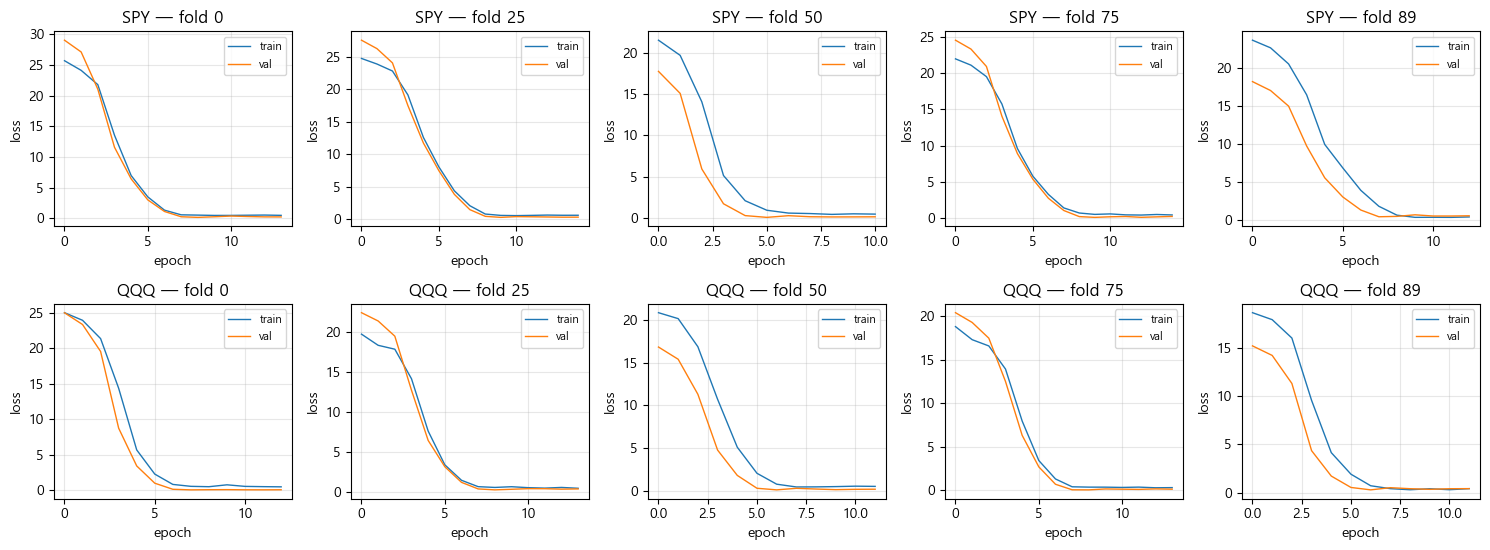

In [10]:
import matplotlib.pyplot as plt

def plot_learning_curves(folds_out_dict, sample_folds_idx=(0, 25, 50, 75, 89)):
    """선택 fold 의 train/val loss curve 비교."""
    n_folds_max = len(next(iter(folds_out_dict.values())))
    selected = [k for k in sample_folds_idx if k < n_folds_max]
    fig, axes = plt.subplots(len(folds_out_dict), len(selected),
                              figsize=(3.0 * len(selected), 2.8 * len(folds_out_dict)),
                              squeeze=False)
    for r, (tk, fo_list) in enumerate(folds_out_dict.items()):
        for c, k in enumerate(selected):
            hist = fo_list[k]['history']
            ax = axes[r, c]
            ax.plot(hist['train_loss'], label='train', lw=1.0)
            ax.plot(hist['val_loss'],   label='val',   lw=1.0)
            ax.set_title(f'{tk} — fold {k}')
            ax.set_xlabel('epoch')
            ax.set_ylabel('loss')
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_learning_curves({'SPY': spy_folds_out, 'QQQ': qqq_folds_out})


### §9.B best_epoch 분포 — EarlyStopping 패턴 진단

`best_epoch == 1` 비율이 높으면 학습 자체가 거의 안 됐음을 의미.


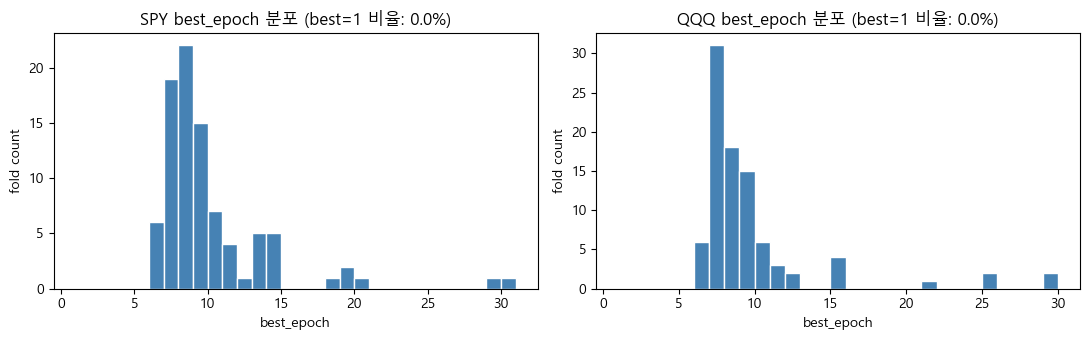

In [11]:
def plot_best_epoch_hist(folds_out_dict):
    fig, axes = plt.subplots(1, len(folds_out_dict), figsize=(11, 3.5))
    for ax, (tk, fo_list) in zip(axes, folds_out_dict.items()):
        bes = [fo['best_epoch'] for fo in fo_list]
        ax.hist(bes, bins=range(1, max(bes)+2), color='steelblue', edgecolor='white')
        ratio_1 = sum(1 for e in bes if e == 1) / len(bes)
        ax.set_title(f'{tk} best_epoch 분포 (best=1 비율: {ratio_1:.1%})')
        ax.set_xlabel('best_epoch')
        ax.set_ylabel('fold count')
    plt.tight_layout()
    plt.show()

plot_best_epoch_hist({'SPY': spy_folds_out, 'QQQ': qqq_folds_out})


### §9.C 예측 분포 sanity (PLAN §6 관문 3 — pred_std_ratio > 0.5)

전체 fold 의 (y_true_test, y_pred_test) 모음에서 pred 분포가 true 분포의 일부를 포착하는지.

**관문**: ``pred_std / true_std > 0.5`` 면 PASS (mean-collapse 회피).


C:\Users\gorhk\AppData\Local\Temp\ipykernel_10608\1047913523.py:15: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


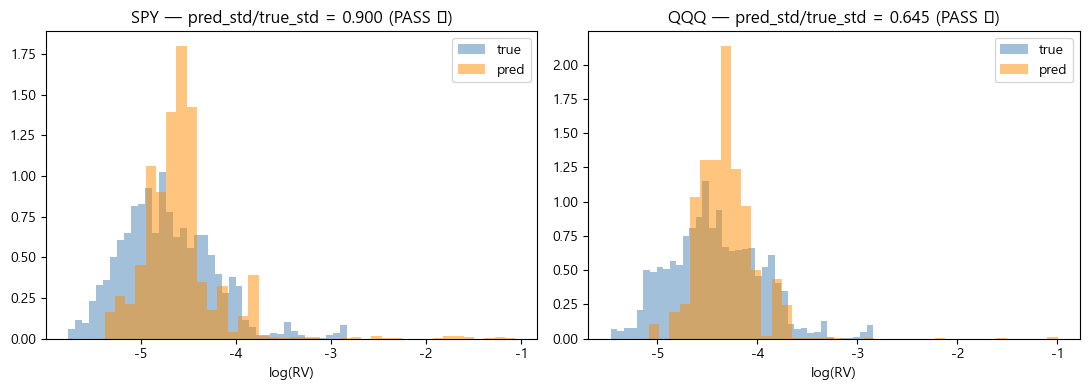

In [12]:
def plot_pred_distribution(folds_out_dict):
    fig, axes = plt.subplots(1, len(folds_out_dict), figsize=(11, 4))
    for ax, (tk, fo_list) in zip(axes, folds_out_dict.items()):
        all_true = np.concatenate([fo['y_true_test'] for fo in fo_list])
        all_pred = np.concatenate([fo['y_pred_test'] for fo in fo_list])
        std_t = float(all_true.std())
        std_p = float(all_pred.std())
        ratio = std_p / std_t if std_t > 0 else float('nan')
        ax.hist(all_true, bins=40, alpha=0.5, label='true', color='steelblue', density=True)
        ax.hist(all_pred, bins=40, alpha=0.5, label='pred', color='darkorange', density=True)
        ax.set_title(f'{tk} — pred_std/true_std = {ratio:.3f} '
                     f'({"PASS ✓" if ratio > 0.5 else "FAIL — mean-collapse"})')
        ax.set_xlabel('log(RV)')
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_pred_distribution({'SPY': spy_folds_out, 'QQQ': qqq_folds_out})


### §9.D 잔차 시계열 + MZ 산점도

- 잔차 (y_pred - y_true) 시간 추이로 체제 편향 검출
- MZ 산점도: y_true vs y_pred + 1:1 선 + OLS 적합선

α=0, β=1 가까울수록 unbiased.


C:\Users\gorhk\AppData\Local\Temp\ipykernel_10608\3412065645.py:24: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()


C:\Users\gorhk\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


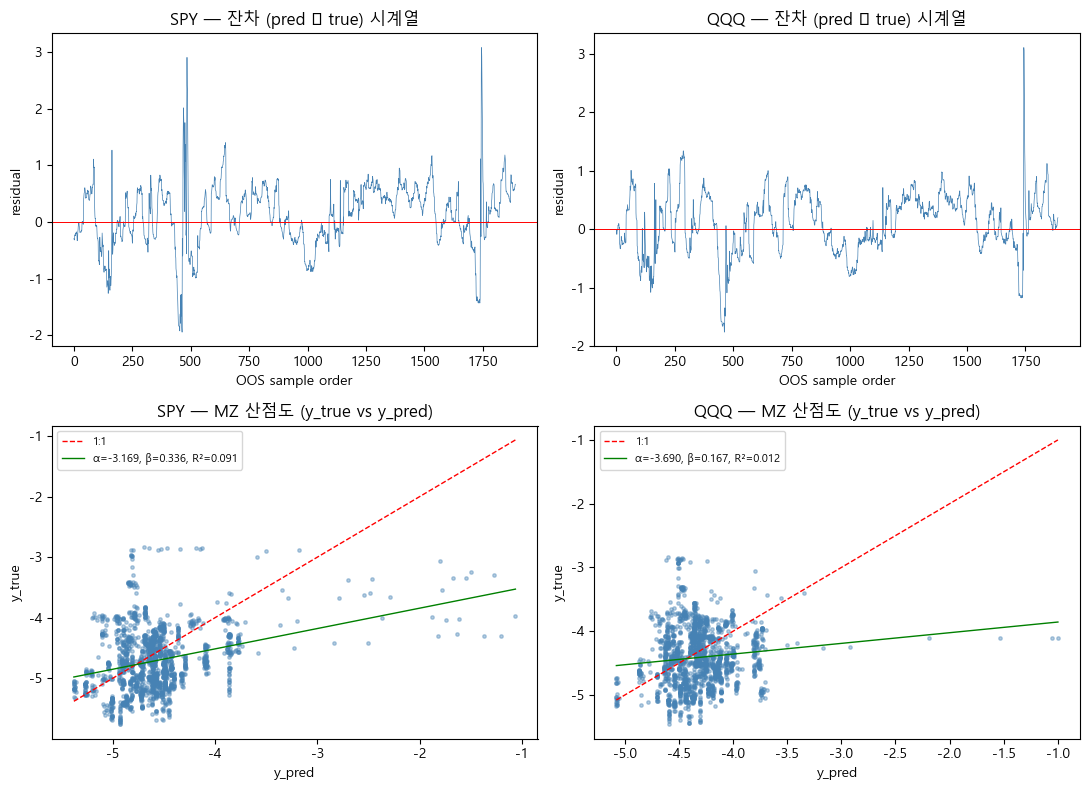

In [13]:
def plot_residual_and_mz(folds_out_dict):
    fig, axes = plt.subplots(2, len(folds_out_dict), figsize=(11, 8))
    for c, (tk, fo_list) in enumerate(folds_out_dict.items()):
        all_true = np.concatenate([fo['y_true_test'] for fo in fo_list])
        all_pred = np.concatenate([fo['y_pred_test'] for fo in fo_list])
        # 잔차 시계열 (fold 순서 = 시간순)
        residual = all_pred - all_true
        axes[0, c].plot(residual, lw=0.5, color='steelblue')
        axes[0, c].axhline(0, color='red', lw=0.7)
        axes[0, c].set_title(f'{tk} — 잔차 (pred − true) 시계열')
        axes[0, c].set_xlabel('OOS sample order')
        axes[0, c].set_ylabel('residual')
        # MZ 산점도
        mz = mz_regression(all_true, all_pred)
        axes[1, c].scatter(all_pred, all_true, s=6, alpha=0.4, color='steelblue')
        x_line = np.linspace(all_pred.min(), all_pred.max(), 100)
        axes[1, c].plot(x_line, x_line, 'r--', lw=1, label='1:1')
        axes[1, c].plot(x_line, mz['alpha'] + mz['beta'] * x_line, 'g-', lw=1,
                         label=f"α={mz['alpha']:.3f}, β={mz['beta']:.3f}, R²={mz['r2']:.3f}")
        axes[1, c].set_title(f'{tk} — MZ 산점도 (y_true vs y_pred)')
        axes[1, c].set_xlabel('y_pred')
        axes[1, c].set_ylabel('y_true')
        axes[1, c].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_residual_and_mz({'SPY': spy_folds_out, 'QQQ': qqq_folds_out})


### §9.E 박스플롯 — fold 별 메트릭 분포

체제 변화 (COVID, 긴축 등) 에 의한 fold-level outlier 진단.


C:\Users\gorhk\AppData\Local\Temp\ipykernel_10608\4006166014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10608\4006166014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10608\4006166014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10608\4006166014.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

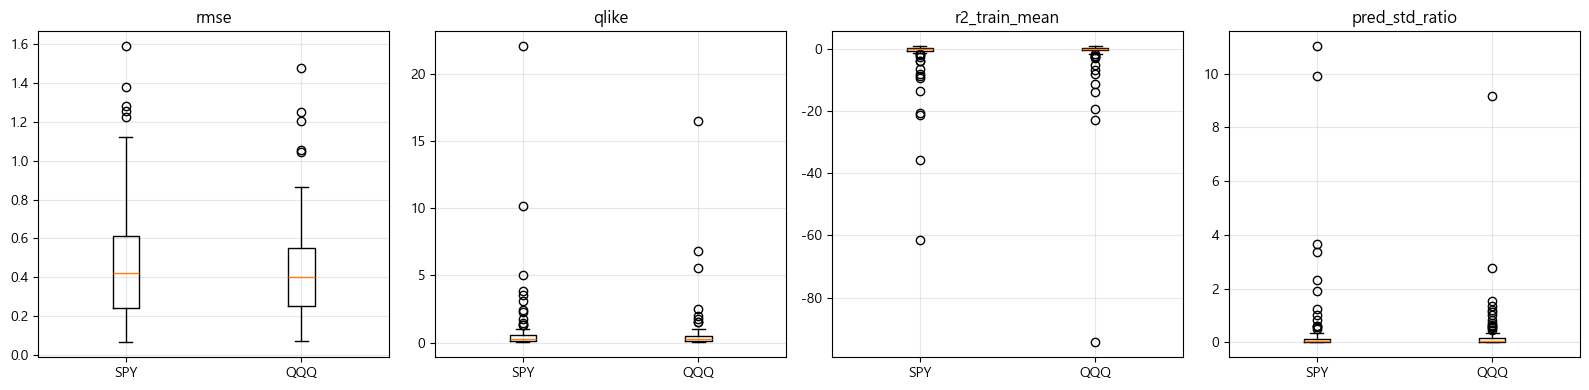

In [14]:
def plot_metric_boxplots(per_fold_dict):
    metrics = ['rmse', 'qlike', 'r2_train_mean', 'pred_std_ratio']
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
    for ax, m in zip(axes, metrics):
        data = []
        labels = []
        for tk, pf in per_fold_dict.items():
            vals = [d[m] for d in pf if not np.isnan(d[m])]
            data.append(vals)
            labels.append(tk)
        ax.boxplot(data, labels=labels)
        ax.set_title(m)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_boxplots({'SPY': per_fold_spy, 'QQQ': per_fold_qqq})


### §9.F train/val/test 갭 — 과적합 정량화

각 fold 의 train/val/test 에서 동일 메트릭(RMSE) 차이가 크면 과적합.


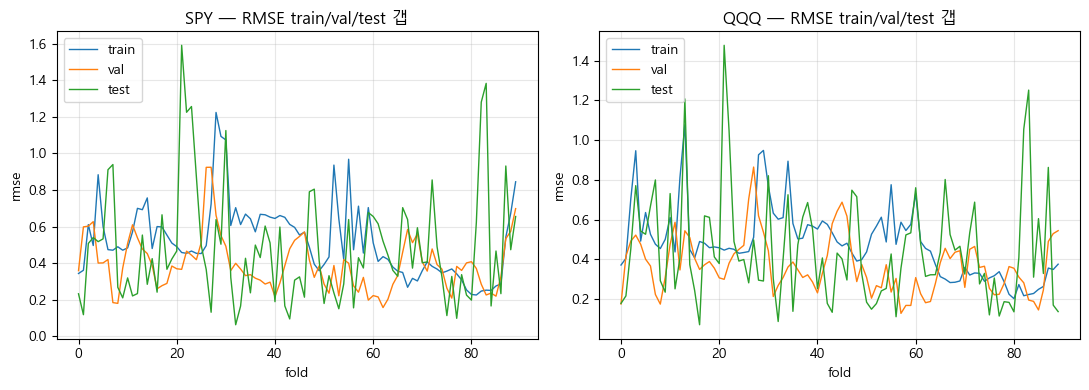


RMSE 갭 평균 (test - train, 양수일수록 과적합 신호):
  SPY: -0.0448
  QQQ: -0.0360


In [15]:
def compute_train_val_test_gap(folds_out):
    rows = []
    for fo in folds_out:
        y_tr = np.array(fo['y_true_train']); p_tr = np.array(fo['y_pred_train'])
        y_va = np.array(fo['y_true_val']);   p_va = np.array(fo['y_pred_val'])
        y_te = np.array(fo['y_true_test']);  p_te = np.array(fo['y_pred_test'])
        rows.append({
            'fold': fo['fold'],
            'rmse_train': rmse(y_tr, p_tr),
            'rmse_val':   rmse(y_va, p_va),
            'rmse_test':  rmse(y_te, p_te),
        })
    return pd.DataFrame(rows)

gap_spy = compute_train_val_test_gap(spy_folds_out)
gap_qqq = compute_train_val_test_gap(qqq_folds_out)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (tk, gap) in zip(axes, [('SPY', gap_spy), ('QQQ', gap_qqq)]):
    ax.plot(gap['fold'], gap['rmse_train'], label='train', lw=1)
    ax.plot(gap['fold'], gap['rmse_val'],   label='val',   lw=1)
    ax.plot(gap['fold'], gap['rmse_test'],  label='test',  lw=1)
    ax.set_title(f'{tk} — RMSE train/val/test 갭')
    ax.set_xlabel('fold')
    ax.set_ylabel('rmse')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nRMSE 갭 평균 (test - train, 양수일수록 과적합 신호):')
for tk, gap in [('SPY', gap_spy), ('QQQ', gap_qqq)]:
    diff = (gap['rmse_test'] - gap['rmse_train']).mean()
    print(f'  {tk}: {diff:.4f}')


## §10. 결론 + metrics.json 저장

`results/volatility_lstm/{SPY,QQQ}/metrics.json` 에 다음 직렬화:
- summary: 90 fold 메트릭 요약
- per_fold: 각 fold 메트릭 + y_true / y_pred (재현·재분석용)
- hyperparams: seed, IS, embargo, seq_len, model, loss, optimizer

§03 베이스라인 비교 노트북이 이 JSON 을 로드하여 HAR-RV / EWMA / Naive 와 비교.


In [16]:
import json

OUT_DIR = RESULTS_DIR / 'volatility_lstm'
OUT_DIR.mkdir(parents=True, exist_ok=True)

hyperparams = {
    'seed': 42,
    'analysis_period': [ANALYSIS_START, ANALYSIS_END],
    'walk_forward': {
        'IS': IS_LEN, 'purge': PURGE, 'embargo': EMBARGO,
        'OOS': OOS_LEN, 'step': STEP, 'n_folds': N_FOLDS,
    },
    'model': {
        'class': 'LSTMRegressor',
        'input_size': INPUT_SIZE, 'hidden_size': HIDDEN,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
        'batch_first': True,
    },
    'training': {
        'loss_type': LOSS_TYPE,
        'max_epochs': MAX_EPOCHS, 'early_stop_patience': PATIENCE,
        'lr': LR, 'weight_decay': WEIGHT_DECAY, 'lr_patience': LR_PATIENCE,
        'val_ratio': VAL_RATIO,
    },
    'seq_len': SEQ_LEN,
    'input_feature': 'log_ret_squared',
    'target': 'log_realized_volatility_21d',
}

for tk, fo_list, pf_list, summary in [
    ('SPY', spy_folds_out, per_fold_spy, summary_spy),
    ('QQQ', qqq_folds_out, per_fold_qqq, summary_qqq),
]:
    out = {
        'ticker': tk,
        'hyperparams': hyperparams,
        'summary': summary,
        'per_fold': pf_list,
        'fold_predictions': fo_list,  # y_true / y_pred 보관 — §03 비교 노트북에서 사용
    }
    out_path = OUT_DIR / f'{tk}_metrics.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    print(f'저장: {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)')

print('\n=' * 70)
print('Phase 1.5 LSTM Step 3 완료 — §03 베이스라인 비교 노트북으로 진행')
print('=' * 70)


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\volatility_lstm\SPY_metrics.json  (2546.2 KB)
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\volatility_lstm\QQQ_metrics.json  (2545.6 KB)

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
Phase 1.5 LSTM Step 3 완료 — §03 베이스라인 비교 노트북으로 진행
